Implementation – Decision Tree(for Classification)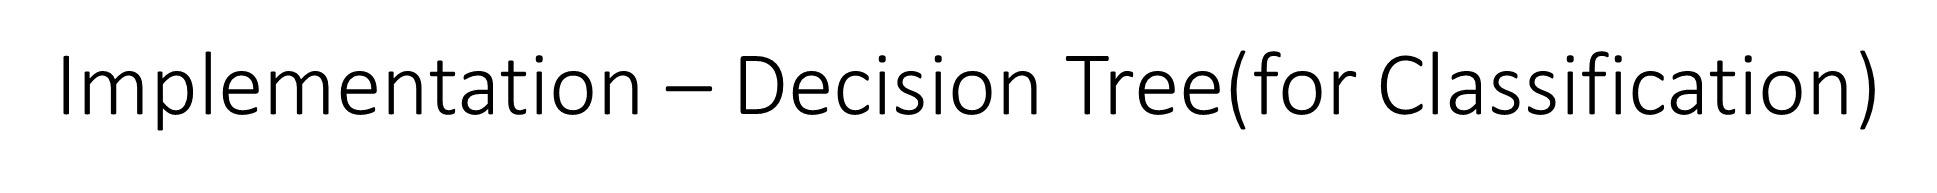

Accuracy: 1.0
Confusion Matrix:
[[10.  0.  0.]
 [ 0.  9.  0.]
 [ 0.  0. 11.]]


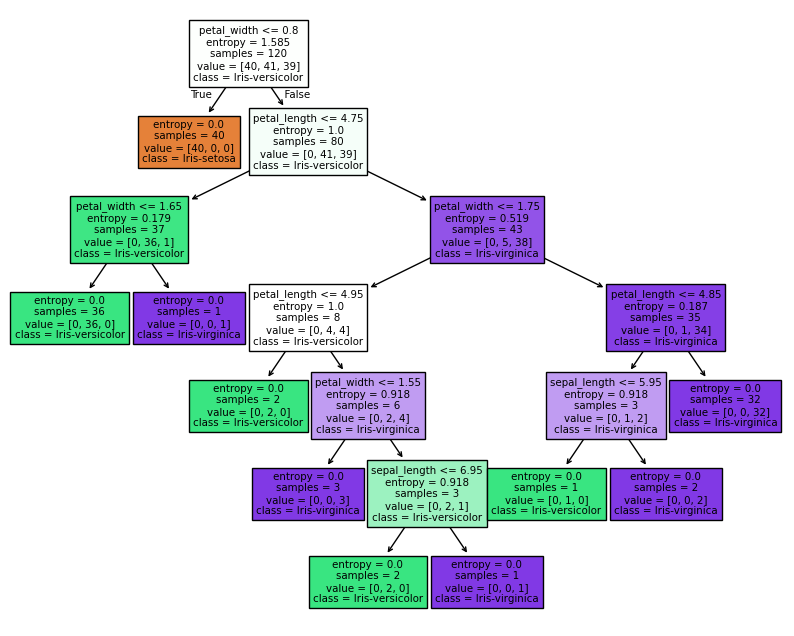

In [13]:
''' Build a DecisionTree classifier to classify IRIS flower dataset
Use 80% of data for training and 20% for testing.
Display accuracy score and confusion matrix of the trained model on test data.
'''

import pandas as pd
import numpy as np
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("iris (1).csv")

# Encode target manually
target_column = df.columns[-1]
classes = df[target_column].unique()
class_map = {c:i for i,c in enumerate(classes)}
df[target_column] = df[target_column].map(class_map)

# Split features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# -------- Manual Accuracy --------
correct = 0
for i in range(len(y_test)):
    if y_test.iloc[i] == y_pred[i]:
        correct += 1

accuracy = correct / len(y_test)
print("Accuracy:", accuracy)

# -------- Manual Confusion Matrix --------
num_classes = len(classes)
conf_matrix = np.zeros((num_classes, num_classes))

for t, p in zip(y_test, y_pred):
    conf_matrix[int(t)][int(p)] += 1

print("Confusion Matrix:")
print(conf_matrix)

# -------- Plot Tree --------
plt.figure(figsize=(10,8))
plot_tree(clf, filled=True,
          feature_names=X.columns,
          class_names=classes)
plt.show()

Accuracy: 1.0
Confusion Matrix:
[[15.  0.  0.  0.  0.]
 [ 0.  5.  0.  0.  0.]
 [ 0.  0. 11.  0.  0.]
 [ 0.  0.  0.  6.  0.]
 [ 0.  0.  0.  0.  3.]]


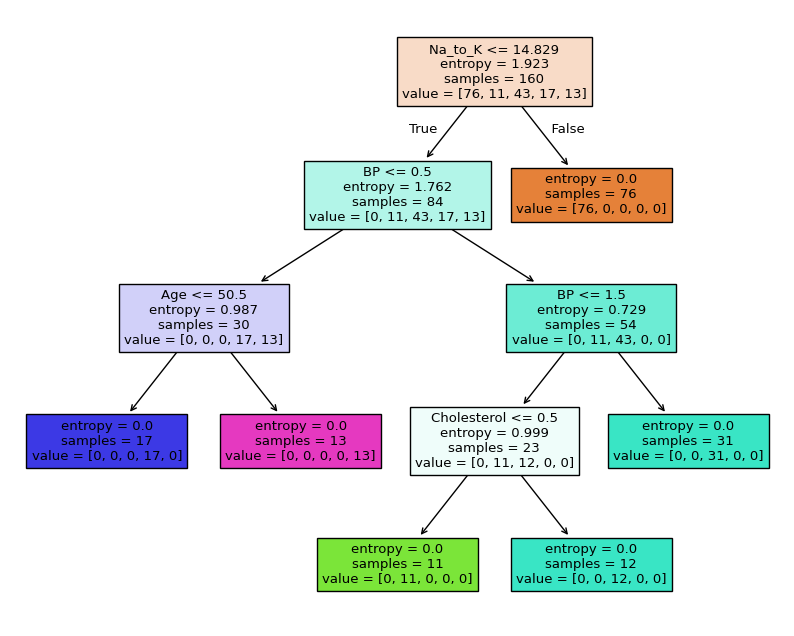

In [11]:
''' Build a DecisionTree classifier to classify Drugdataset
Use 80% of data for training and 20% for testing.
Display accuracy score and confusion matrix of the trained model on test data.
'''

import pandas as pd
import numpy as np
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("drug.csv")

# Encode categorical columns manually
for col in df.columns:
    if df[col].dtype == object:
        unique_vals = df[col].unique()
        mapping = {v:i for i,v in enumerate(unique_vals)}
        df[col] = df[col].map(mapping)

# Split features and target
target_column = df.columns[-1]
X = df.drop(target_column, axis=1)
y = df[target_column]

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# -------- Manual Accuracy --------
correct = 0
for i in range(len(y_test)):
    if y_test.iloc[i] == y_pred[i]:
        correct += 1

accuracy = correct / len(y_test)
print("Accuracy:", accuracy)

# -------- Manual Confusion Matrix --------
num_classes = len(y.unique())
conf_matrix = np.zeros((num_classes, num_classes))

for t, p in zip(y_test, y_pred):
    conf_matrix[int(t)][int(p)] += 1

print("Confusion Matrix:")
print(conf_matrix)

# -------- Plot Tree --------
plt.figure(figsize=(10,8))
plot_tree(clf, filled=True,
          feature_names=X.columns)
plt.show()

In [17]:
''' Build a RegressionTree to predict petrol consumption
Use 80% of data for training and 20% for testing.
Display “Mean Absolute Error, Mean Squared Error, Root Mean Squared Error” for test data.
'''

import pandas as pd
import numpy as np
import math
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("petrol_consumption.csv")

# Split features and target
target_column = df.columns[-1]
X = df.drop(target_column, axis=1)
y = df[target_column]

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Regression Tree
reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)

# Predict
y_pred = reg.predict(X_test)

# -------- Manual MAE --------
mae = 0
for i in range(len(y_test)):
    mae += abs(y_test.iloc[i] - y_pred[i])
mae = mae / len(y_test)

# -------- Manual MSE --------
mse = 0
for i in range(len(y_test)):
    mse += (y_test.iloc[i] - y_pred[i])**2
mse = mse / len(y_test)

# -------- Manual RMSE --------
rmse = math.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)


Mean Absolute Error: 98.4
Mean Squared Error: 18007.8
Root Mean Squared Error: 134.19314438524793
